##*LAB3: Where Hidden Rhythms in Silent Vectors Lie: A Quest into the Emergence of Structures in Character-Level GPT Models* ##

# Where Hidden Rhythms in Silent Vectors Lie
## Exploration de l'émergence de structures dans un modèle GPT au niveau des caractères

---

Ce notebook constitue le rapport et l'implémentation du laboratoire 3. L'objectif est de
construire, entraîner et analyser un modèle de langue autorégressif au niveau des caractères,
entraîné sur un corpus poétique, afin d'étudier comment des structures linguistiques émergent
au cours de l'apprentissage.

Le travail est organisé en quatre étapes :
1. **Architecture du modèle** — implémentation d'un Transformer décodeur
2. **Entraînement** — constitution du corpus et apprentissage
3. **Exploration des hyperparamètres** — analyse de leur impact
4. **Analyse des poèmes générés** — étude des structures émergentes

## Imports et configuration

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import time

# Vérification du dispositif disponible
dispositif = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositif utilisé : {dispositif}")

Dispositif utilisé : cuda


---
# Étape I — Architecture du modèle

Nous implémentons ici un Transformer décodeur (*decoder-only*), architecture sur laquelle
reposent les modèles de la famille GPT. Contrairement à un Transformer encodeur-décodeur
complet, cette architecture ne comprend qu'une pile de blocs de décodage, ce qui suffit
pour la modélisation autorégressive : à chaque pas, le modèle prédit le prochain caractère
à partir de tous ceux qui précèdent.

Le modèle opère au **niveau des caractères** : le vocabulaire est l'ensemble des caractères
distincts présents dans le corpus (lettres, ponctuation, sauts de ligne, etc.). Cela permet
de conserver un vocabulaire très réduit et d'éviter toute étape de tokenisation complexe.

L'architecture comprend les composants suivants, implémentés successivement :
- Embeddings de tokens et positionnels
- Attention causale multi-têtes
- Bloc Feed-Forward
- Bloc Transformer avec connexions résiduelles et normalisation
- Modèle GPT complet

#ajouter commentaire dans rapport pour introduire etc

In [ ]:
class Embeddings(nn.Module):
    """
    Représentation initiale d'une séquence de tokens : somme d'un embedding
    de tokens et d'un embedding positionnel appris.
    """

    def __init__(
        self,
        taille_vocab: int,
        d_modele: int,
        longueur_contexte: int,
        dropout: float = 0.1,
    ):
        """
        Paramètres
        ----------
        taille_vocab        : nombre de caractères distincts dans le vocabulaire
        d_modele            : dimension des vecteurs de représentation
        longueur_contexte   : longueur maximale de séquence acceptée en entrée
        dropout             : taux de dropout appliqué après la somme des embeddings
        """
        super().__init__()

        # Table de correspondance caractère → vecteur de dimension d_modele
        self.emb_token = nn.Embedding(taille_vocab, d_modele)

        # Table de correspondance position → vecteur de dimension d_modele
        self.emb_position = nn.Embedding(longueur_contexte, d_modele)

        self.dropout = nn.Dropout(dropout)
        self.longueur_contexte = longueur_contexte

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x        : (B, T) — indices entiers des caractères
        retourne : (B, T, d_modele)
        """
        B, T = x.shape
        assert T <= self.longueur_contexte, (
            f"Séquence de longueur {T} dépasse le contexte ({self.longueur_contexte})"
        )

        # Positions [0, 1, ..., T-1] partagées pour tout le batch
        positions = torch.arange(T, device=x.device)       # (T,)

        emb_tok = self.emb_token(x)                        # (B, T, d_modele)
        emb_pos = self.emb_position(positions)             # (T, d_modele) → diffusé sur B

        return self.dropout(emb_tok + emb_pos)             # (B, T, d_modele)

### 2. Attention causale multi-têtes

In [ ]:
class AttentionCausaleMultiTetes(nn.Module):
    def __init__(self, d_modele, n_tetes, longueur_contexte, dropout=0.1, mode='optimisee'):
        super().__init__()
        assert d_modele % n_tetes == 0, "d_modele doit être divisible par n_tetes"

        self.n_tetes  = n_tetes
        self.d_tete   = d_modele // n_tetes
        self.d_modele = d_modele
        self.dropout  = dropout
        self.mode     = mode

        self.proj_qkv    = nn.Linear(d_modele, 3 * d_modele, bias=False)
        self.proj_sortie = nn.Linear(d_modele, d_modele, bias=False)
        self.dropout_attn = nn.Dropout(dropout)

        # Masque triangulaire causal pour le mode classique
        masque = torch.tril(torch.ones(longueur_contexte, longueur_contexte)).bool()
        self.register_buffer('masque_causal', masque)

    def _attention_classique(self, q, k, v):
        T = q.size(2)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_tete)
        scores = scores.masked_fill(~self.masque_causal[:T, :T], float('-inf'))
        poids  = self.dropout_attn(F.softmax(scores, dim=-1))
        return torch.matmul(poids, v)

    def _attention_optimisee(self, q, k, v):
        return F.scaled_dot_product_attention(
            q, k, v,
            attn_mask=None,
            dropout_p=self.dropout if self.training else 0.0,
            is_causal=True,
        )

    def forward(self, x):
        B, T, _ = x.shape

        q, k, v = self.proj_qkv(x).split(self.d_modele, dim=-1)

        def decouper(t):
            return t.view(B, T, self.n_tetes, self.d_tete).transpose(1, 2)

        q, k, v = decouper(q), decouper(k), decouper(v)

        if self.mode == 'classique':
            contexte = self._attention_classique(q, k, v)
        else:
            contexte = self._attention_optimisee(q, k, v)

        contexte = contexte.transpose(1, 2).contiguous().view(B, T, self.d_modele)
        return self.proj_sortie(contexte)

#### Benchmark — comparaison des deux implémentations

In [ ]:
def benchmark_attention(mode, n_repetitions=100):
    B, T, d_modele, n_tetes = 32, 256, 256, 8

    modele = AttentionCausaleMultiTetes(
        d_modele=d_modele, n_tetes=n_tetes,
        longueur_contexte=T, dropout=0.0, mode=mode
    ).to(dispositif)

    entree = torch.randn(B, T, d_modele, device=dispositif)

    # Échauffement
    with torch.no_grad():
        for _ in range(10):
            modele(entree)

    if dispositif.type == 'cuda':
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    debut = time.perf_counter()
    with torch.no_grad():
        for _ in range(n_repetitions):
            modele(entree)
    if dispositif.type == 'cuda':
        torch.cuda.synchronize()
    fin = time.perf_counter()

    temps_ms = (fin - debut) / n_repetitions * 1000
    memoire_mo = (
        torch.cuda.max_memory_allocated() / 1024**2
        if dispositif.type == 'cuda' else float('nan')
    )
    print(f"[{mode:>10}]  Temps : {temps_ms:.3f} ms  |  Mémoire GPU : {memoire_mo:.1f} Mo")

benchmark_attention('classique')
benchmark_attention('optimisee')

[ classique]  Temps : 4.936 ms  |  Mémoire GPU : 185.2 Mo
[ optimisee]  Temps : 1.796 ms  |  Mémoire GPU : 57.2 Mo


### 3. Bloc Feed-Forward

In [ ]:
class BlocFeedForward(nn.Module):
    def __init__(self, d_modele, facteur_expansion=4, dropout=0.1):
        super().__init__()
        self.reseau = nn.Sequential(
            nn.Linear(d_modele, facteur_expansion * d_modele),
            nn.GELU(),
            nn.Linear(facteur_expansion * d_modele, d_modele),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.reseau(x)

### 4. Bloc Transformer

In [ ]:
class BlocTransformer(nn.Module):
    def __init__(self, d_modele, n_tetes, longueur_contexte, dropout=0.1, mode='optimisee'):
        super().__init__()
        self.norme_1    = nn.LayerNorm(d_modele)
        self.attention  = AttentionCausaleMultiTetes(d_modele, n_tetes, longueur_contexte, dropout, mode)
        self.norme_2    = nn.LayerNorm(d_modele)
        self.ff         = BlocFeedForward(d_modele, dropout=dropout)

    def forward(self, x):
        # Connexion résiduelle autour de l'attention
        x = x + self.attention(self.norme_1(x))
        # Connexion résiduelle autour du feed-forward
        x = x + self.ff(self.norme_2(x))
        return x

### 5. Modèle GPT complet

In [ ]:
class GPT(nn.Module):
    def __init__(self, taille_vocab, d_modele, n_tetes, n_couches, longueur_contexte, dropout=0.1, mode='optimisee'):
        super().__init__()

        self.embeddings = Embeddings(taille_vocab, d_modele, longueur_contexte, dropout)

        self.blocs = nn.Sequential(*[
            BlocTransformer(d_modele, n_tetes, longueur_contexte, dropout, mode)
            for _ in range(n_couches)
        ])

        self.norme_finale = nn.LayerNorm(d_modele)

        # Projection vers le vocabulaire
        self.tete_lm = nn.Linear(d_modele, taille_vocab, bias=False)

        # Partage des poids entre l'embedding de tokens et la tête de projection
        self.tete_lm.weight = self.embeddings.emb_token.weight

        # Initialisation des poids
        self.appliquer_init()

    def appliquer_init(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, mean=0.0, std=0.02)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Embedding):
                nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, x, cibles=None):
        """
        x       : (B, T) — indices des caractères en entrée
        cibles  : (B, T) — indices des caractères cibles (optionnel)
        """
        x = self.embeddings(x)
        x = self.blocs(x)
        x = self.norme_finale(x)
        logits = self.tete_lm(x)              # (B, T, taille_vocab)

        perte = None
        if cibles is not None:
            perte = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                cibles.view(-1),
            )

        return logits, perte

    @torch.no_grad()
    def generer(self, x, longueur_max, temperature=1.0, top_k=None):
        """
        Génère des caractères de façon autorégressive à partir d'un prompt x.

        x            : (1, T) — prompt initial
        longueur_max : nombre de caractères à générer
        temperature  : contrôle la créativité (< 1 = plus déterministe)
        top_k        : si défini, restreint l'échantillonnage aux k meilleurs tokens
        """
        for _ in range(longueur_max):
            # Tronquer si la séquence dépasse la longueur de contexte
            x_tronque = x[:, -self.embeddings.longueur_contexte:]

            logits, _ = self(x_tronque)

            # On ne garde que les logits du dernier token
            logits = logits[:, -1, :] / temperature

            # Top-k optionnel
            if top_k is not None:
                valeurs, _ = torch.topk(logits, top_k)
                logits[logits < valeurs[:, [-1]]] = float('-inf')

            probs = F.softmax(logits, dim=-1)
            prochain = torch.multinomial(probs, num_samples=1)  # (1, 1)
            x = torch.cat([x, prochain], dim=1)

        return x

### 6. Instanciation du modèle

In [ ]:
# Configuration suggérée par le sujet
config = {
    'taille_vocab'       : 100,    # à remplacer après construction du vocabulaire
    'd_modele'           : 256,
    'n_tetes'            : 8,
    'n_couches'          : 6,
    'longueur_contexte'  : 256,
    'dropout'            : 0.1,
    'mode'               : 'optimisee',
}

modele = GPT(**config).to(dispositif)

n_params = sum(p.numel() for p in modele.parameters())
print(f"Nombre de paramètres : {n_params:,}")

Nombre de paramètres : 4,824,064


## Étape II — Corpus et entraînement

### 1. Constitution du corpus

Nous constituons un corpus de poésie française à partir de textes libres de droits
disponibles sur le Projet Gutenberg. Les auteurs retenus sont Victor Hugo, Charles
Baudelaire et Paul Verlaine, dont les œuvres présentent des structures poétiques
marquées (alexandrins, strophes régulières, schémas de rimes) favorables à l'étude
de l'émergence de structures dans le modèle.

In [ ]:
import requests

# Textes libres de droits sur le Projet Gutenberg
sources = {
    'Hugo - Les Contemplations'      : 'https://www.gutenberg.org/cache/epub/29843/pg29843.txt',
    'Baudelaire - Les Fleurs du Mal' : 'https://www.gutenberg.org/cache/epub/6099/pg6099.txt',
    'Verlaine - all oeuvres'   : 'https://www.gutenberg.org/cache/epub/15112/pg15112.txt',
    'Rimbaud - Poésies'              : 'https://www.gutenberg.org/cache/epub/29302/pg29302.txt',
}

def telecharger_texte(url):
    reponse = requests.get(url, timeout=10)
    reponse.encoding = 'utf-8'
    return reponse.text

corpus_brut = []
for titre, url in sources.items():
    try:
        texte = telecharger_texte(url)
        corpus_brut.append(texte)
        print(f"✓ {titre} — {len(texte):,} caractères")
    except Exception as e:
        print(f"✗ {titre} — erreur : {e}")

corpus_complet = '\n\n'.join(corpus_brut)
print(f"\nTaille totale du corpus : {len(corpus_complet) / 1e6:.2f} Mo")

✓ Hugo - Les Contemplations — 254,427 caractères
✓ Baudelaire - Les Fleurs du Mal — 180,205 caractères
✓ Verlaine - all oeuvres — 293,773 caractères
✓ Rimbaud - Poésies — 134,494 caractères

Taille totale du corpus : 0.86 Mo


### 2. Nettoyage du corpus

Les fichiers Gutenberg contiennent des en-têtes et pieds de page légaux qu'il convient
de supprimer. On préserve les sauts de ligne, les séparations de strophes et la
ponctuation, essentiels pour l'étude de la forme poétique.

In [ ]:
import re

def nettoyer_gutenberg(texte):
    # Suppression de l'en-tête Gutenberg
    debut = re.search(r'\*\*\* START OF (THIS|THE) PROJECT GUTENBERG', texte)
    fin   = re.search(r'\*\*\* END OF (THIS|THE) PROJECT GUTENBERG', texte)

    if debut:
        texte = texte[debut.end():]
    if fin:
        texte = texte[:fin.start()]

    # Suppression des retours chariot Windows
    texte = texte.replace('\r\n', '\n').replace('\r', '\n')

    # Suppression des lignes de plus de 3 sauts de ligne consécutifs
    texte = re.sub(r'\n{4,}', '\n\n\n', texte)

    return texte.strip()

corpus_nettoye = '\n\n'.join([nettoyer_gutenberg(t) for t in corpus_brut])
print(f"Taille après nettoyage : {len(corpus_nettoye) / 1e6:.2f} Mo")
print(f"\nExtrait :\n{corpus_nettoye[:500]}")

Taille après nettoyage : 0.76 Mo

Extrait :
EBOOK LES CONTEMPLATIONS: AUTREFOIS, 1830-1843 ***


Produced by Adrian Mastronardi, Rénald Lévesque and the
Online Distributed Proofreading Team at http://www.pgdp.net
(This file was produced from images generously made
available by the Bibliothèque nationale de France
(BnF/Gallica)


LES
CONTEMPLATIONS

PAR

VICTOR HUGO


I

AUTREFOIS.--1830-1843

Cinquième Édition


COLLECTION HETZEL

PARIS
LIBRAIRIE L. HACHETTE ET Cie
RUE PIERRE-SARRAZIN, 14

1858


Tous droits réservés


Si un auteur pouvai


### 3. Tokenisation au niveau des caractères

In [ ]:
# Construction du vocabulaire : ensemble des caractères distincts du corpus
caracteres = sorted(set(corpus_nettoye))
taille_vocab = len(caracteres)
print(f"Taille du vocabulaire : {taille_vocab} caractères")
print(f"Caractères : {''.join(caracteres)}")

# Tables de correspondance caractère ↔ indice
car_vers_idx = {c: i for i, c in enumerate(caracteres)}
idx_vers_car = {i: c for i, c in enumerate(caracteres)}

# Fonctions d'encodage et de décodage
encoder  = lambda texte   : [car_vers_idx[c] for c in texte]
decoder  = lambda indices : ''.join([idx_vers_car[i] for i in indices])

# Encodage du corpus complet
donnees = torch.tensor(encoder(corpus_nettoye), dtype=torch.long)
print(f"\nNombre total de tokens : {len(donnees):,}")

Taille du vocabulaire : 113 caractères
Caractères : 
 !"'()*,-./0123456789:;=>?ABCDEFGHIJKLMNOPQRSTUVWXYZ[]_abcdefghijklmnopqrstuvwxyz«·»ÀÂÇÈÉÊËÎÏÔàâæçèéêëîïñôùûüŒ—™

Nombre total de tokens : 762,939


### 4. Découpage train / validation

In [ ]:
n = int(0.9 * len(donnees))
donnees_entrainement = donnees[:n]
donnees_validation   = donnees[n:]

print(f"Entraînement : {len(donnees_entrainement):,} tokens")
print(f"Validation   : {len(donnees_validation):,} tokens")

Entraînement : 686,645 tokens
Validation   : 76,294 tokens


In [ ]:
print(corpus_nettoye[:2000])

EBOOK LES CONTEMPLATIONS: AUTREFOIS, 1830-1843 ***


Produced by Adrian Mastronardi, Rénald Lévesque and the
Online Distributed Proofreading Team at http://www.pgdp.net
(This file was produced from images generously made
available by the Bibliothèque nationale de France
(BnF/Gallica)


LES
CONTEMPLATIONS

PAR

VICTOR HUGO


I

AUTREFOIS.--1830-1843

Cinquième Édition


COLLECTION HETZEL

PARIS
LIBRAIRIE L. HACHETTE ET Cie
RUE PIERRE-SARRAZIN, 14

1858


Tous droits réservés


Si un auteur pouvait avoir quelque droit d'influer sur la disposition
d'esprit des lecteurs qui ouvrent son livre, l'auteur des
_Contemplations_ se bornerait à dire ceci: Ce livre doit être lu comme
on lirait le livre d'un mort.

Vingt-cinq années sont dans ces deux volumes. _Grande mortalis ævi
spatium_. L'auteur a laissé, pour ainsi dire, ce livre se faire en lui.
La vie, en filtrant goutte à goutte à travers les événements et les
souffrances, l'a déposé dans son coeur. Ceux qui s'y pencheront
retrouveront leur 

### 5. Chargeur de batches

In [ ]:
def obtenir_batch(split, taille_batch=32, longueur_contexte=256):
    """
    Échantillonne aléatoirement un batch de séquences dans le corpus.

    split          : 'entrainement' ou 'validation'
    taille_batch   : nombre de séquences par batch
    longueur_contexte : longueur de chaque séquence
    """
    donnees_split = (
        donnees_entrainement if split == 'entrainement'
        else donnees_validation
    )

    # Indices de départ aléatoires
    indices = torch.randint(
        len(donnees_split) - longueur_contexte, (taille_batch,)
    )

    x = torch.stack([donnees_split[i:i+longueur_contexte]   for i in indices])
    y = torch.stack([donnees_split[i+1:i+longueur_contexte+1] for i in indices])

    return x.to(dispositif), y.to(dispositif)


# Vérification
x, y = obtenir_batch('entrainement')
print(f"Forme de x : {x.shape}")
print(f"Forme de y : {y.shape}")

Forme de x : torch.Size([32, 256])
Forme de y : torch.Size([32, 256])


### 6. Boucle d'entraînement

In [ ]:
config = {
    'taille_vocab'      : taille_vocab,
    'd_modele'          : 256,
    'n_tetes'           : 8,
    'n_couches'         : 6,
    'longueur_contexte' : 256,
    'dropout'           : 0.1,
    'mode'              : 'optimisee',
}

TAILLE_BATCH      = 32
N_STEPS           = 20000
TAUX_APPRENTISSAGE = 3e-4
INTERVALLE_EVAL   = 1000
INTERVALLE_GENE   = 5000
N_STEPS_EVAL      = 20

# Instanciation du modèle
modele = GPT(**config).to(dispositif)
optimiseur = torch.optim.AdamW(modele.parameters(), lr=TAUX_APPRENTISSAGE)

# Planificateur de taux d'apprentissage avec échauffement linéaire
def obtenir_taux(step, n_warmup=1000):
    if step < n_warmup:
        return step / n_warmup
    return 1.0

planificateur = torch.optim.lr_scheduler.LambdaLR(optimiseur, obtenir_taux)

# Historique
historique = {
    'steps'       : [],
    'perte_train' : [],
    'perte_val'   : [],
    'bpc_train'   : [],
    'bpc_val'     : [],
}

@torch.no_grad()
def evaluer():
    """Calcule la perte moyenne sur le corpus de validation."""
    modele.eval()
    pertes = []
    for _ in range(N_STEPS_EVAL):
        x, y = obtenir_batch('validation', TAILLE_BATCH, config['longueur_contexte'])
        _, perte = modele(x, y)
        pertes.append(perte.item())
    modele.train()
    return sum(pertes) / len(pertes)

def generer_exemple(longueur=200, temperature=0.8):
    """Génère un extrait de poème à partir d'un prompt vide."""
    modele.eval()
    prompt = torch.zeros((1, 1), dtype=torch.long, device=dispositif)
    indices = modele.generer(prompt, longueur, temperature=temperature)[0].tolist()
    modele.train()
    return decoder(indices)

# Boucle principale
modele.train()
for step in range(N_STEPS):
    x, y = obtenir_batch('entrainement', TAILLE_BATCH, config['longueur_contexte'])

    _, perte = modele(x, y)
    optimiseur.zero_grad()
    perte.backward()

    # Écrêtage du gradient pour stabiliser l'entraînement
    torch.nn.utils.clip_grad_norm_(modele.parameters(), 1.0)

    optimiseur.step()
    planificateur.step()

    # Évaluation périodique
    if step % INTERVALLE_EVAL == 0:
        perte_val = evaluer()
        perte_train = perte.item()
        bpc_train = perte_train / math.log(2)
        bpc_val   = perte_val   / math.log(2)

        historique['steps'].append(step)
        historique['perte_train'].append(perte_train)
        historique['perte_val'].append(perte_val)
        historique['bpc_train'].append(bpc_train)
        historique['bpc_val'].append(bpc_val)

        print(
            f"Step {step:>6} | "
            f"Perte train : {perte_train:.4f} | "
            f"Perte val : {perte_val:.4f} | "
            f"BPC val : {bpc_val:.4f} | "
            f"LR : {planificateur.get_last_lr()[0]*TAUX_APPRENTISSAGE:.2e}"
        )

    # Génération périodique d'un exemple
    if step % INTERVALLE_GENE == 0:
        print(f"\n--- Exemple généré (step {step}) ---")
        print(generer_exemple())
        print("-----------------------------------\n")

Step      0 | Perte train : 4.9032 | Perte val : 4.8962 | BPC val : 7.0638 | LR : 9.00e-11

--- Exemple généré (step 0) ---

ÎZnKù»_Ç"yh9æ2LRçW0çTDVüçÇ3=mkè;üN5À!jKR>=3wû,ôÏÏeDdÊ;Ï>æw«mkÊEDWûÇGv4SZç0mà2eïùKéÔÔ·ùoëRX/æe"7Tù™=HK,qÎ>îEu—
êNA«;iŒL9éBAùïËÀYoù
ZùùaWUCËû BüNokPñÎ3ÔSvc8Â4e2ñiAE?ûéA50t!0üPl/ü;3h-FqîâOéCcK"ïWèb:S9tQâ
-----------------------------------

Step   1000 | Perte train : 1.8858 | Perte val : 1.8711 | BPC val : 2.6994 | LR : 9.00e-08
Step   2000 | Perte train : 1.4960 | Perte val : 1.5227 | BPC val : 2.1968 | LR : 9.00e-08
Step   3000 | Perte train : 1.3172 | Perte val : 1.4454 | BPC val : 2.0853 | LR : 9.00e-08
Step   4000 | Perte train : 1.1805 | Perte val : 1.4359 | BPC val : 2.0715 | LR : 9.00e-08
Step   5000 | Perte train : 1.0630 | Perte val : 1.5021 | BPC val : 2.1671 | LR : 9.00e-08

--- Exemple généré (step 5000) ---

                                                                                 533
                                                            

In [ ]:
if step % 5000 == 0 and step > 0:
    torch.save({
        'config'      : config,
        'poids'       : modele.state_dict(),
        'vocabulaire' : car_vers_idx,
        'historique'  : historique,
        'step'        : step,
    }, f'checkpoint_step_{step}.pt')
    print(f"✓ Checkpoint sauvegardé à step {step}")

### 7. Visualisation des courbes d'apprentissage

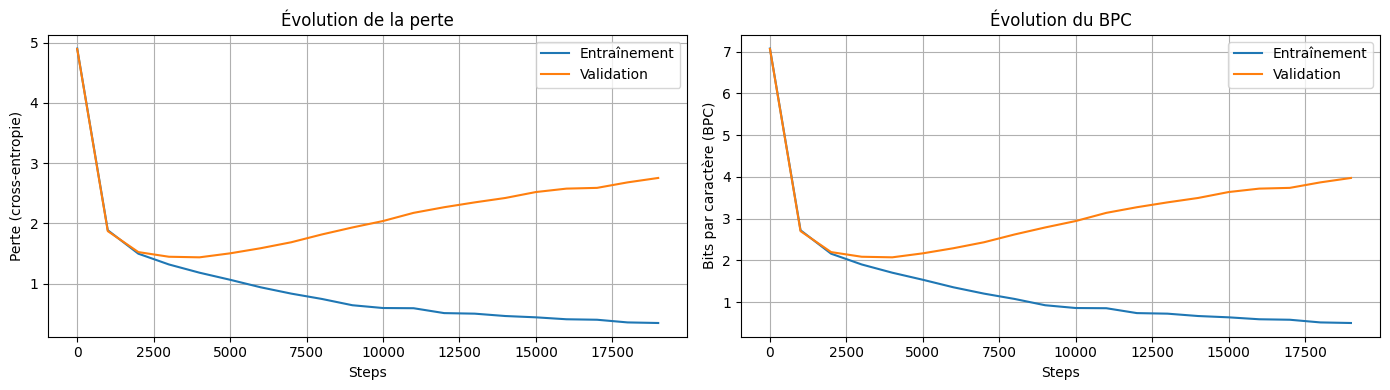

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Pertes
ax1.plot(historique['steps'], historique['perte_train'], label='Entraînement')
ax1.plot(historique['steps'], historique['perte_val'],   label='Validation')
ax1.set_xlabel('Steps')
ax1.set_ylabel('Perte (cross-entropie)')
ax1.set_title('Évolution de la perte')
ax1.legend()
ax1.grid(True)

# Bits par caractère
ax2.plot(historique['steps'], historique['bpc_train'], label='Entraînement')
ax2.plot(historique['steps'], historique['bpc_val'],   label='Validation')
ax2.set_xlabel('Steps')
ax2.set_ylabel('Bits par caractère (BPC)')
ax2.set_title('Évolution du BPC')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('courbes_apprentissage.png', dpi=150)
plt.show()

In [ ]:
torch.save({
    'config'      : config,
    'poids'       : modele.state_dict(),
    'vocabulaire' : car_vers_idx,
    'historique'  : historique,
}, 'modele_gpt_poesie.pt')

print("Modèle sauvegardé.")

Modèle sauvegardé.


## Étape III — Exploration des hyperparamètres

Nous étudions l'impact de trois hyperparamètres sur le comportement du modèle :
le nombre de couches, la dimension cachée et le taux de dropout. Pour chaque
configuration, on entraîne un modèle réduit (10k steps) et on compare la perte
de validation finale.

In [30]:
def entrainer_configuration(config, n_steps=10000, taille_batch=32):
    """
    Entraîne un modèle GPT avec la configuration donnée et retourne l'historique.

    Paramètres
    ----------
    config    : dictionnaire de configuration du modèle
    n_steps   : nombre de steps d'entraînement
    taille_batch : taille du batch

    Retourne
    --------
    Dictionnaire contenant les pertes et BPC enregistrés
    """
    modele_exp = GPT(**config).to(dispositif)
    optimiseur_exp = torch.optim.AdamW(modele_exp.parameters(), lr=3e-4)

    historique_exp = {
        'steps'       : [],
        'perte_train' : [],
        'perte_val'   : [],
        'bpc_val'     : [],
    }

    modele_exp.train()
    for step in range(n_steps):
        x, y = obtenir_batch('entrainement', taille_batch, config['longueur_contexte'])
        _, perte = modele_exp(x, y)
        optimiseur_exp.zero_grad()
        perte.backward()
        torch.nn.utils.clip_grad_norm_(modele_exp.parameters(), 1.0)
        optimiseur_exp.step()

        if step % 500 == 0:
            # Évaluation rapide
            modele_exp.eval()
            pertes_val = []
            with torch.no_grad():
                for _ in range(20):
                    xv, yv = obtenir_batch('validation', taille_batch, config['longueur_contexte'])
                    _, pv = modele_exp(xv, yv)
                    pertes_val.append(pv.item())
            modele_exp.train()

            perte_val = sum(pertes_val) / len(pertes_val)
            historique_exp['steps'].append(step)
            historique_exp['perte_train'].append(perte.item())
            historique_exp['perte_val'].append(perte_val)
            historique_exp['bpc_val'].append(perte_val / math.log(2))

    n_params = sum(p.numel() for p in modele_exp.parameters())
    print(
        f"Config : {config['n_couches']} couches | "
        f"d={config['d_modele']} | "
        f"dropout={config['dropout']} | "
        f"Params : {n_params:,} | "
        f"BPC val final : {historique_exp['bpc_val'][-1]:.4f}"
    )

    return historique_exp

In [32]:
# Configuration de base
config_base = {
    'taille_vocab'      : taille_vocab,
    'd_modele'          : 256,
    'n_tetes'           : 8,
    'n_couches'         : 6,
    'longueur_contexte' : 256,
    'dropout'           : 0.1,
    'mode'              : 'optimisee',
}

# --- Expérience 1 : impact du nombre de couches ---
print("=== Expérience 1 : nombre de couches ===")
resultats_couches = {}
for n_couches in [2, 4, 6]:
    config_exp = {**config_base, 'n_couches': n_couches}
    resultats_couches[n_couches] = entrainer_configuration(config_exp, n_steps=5000)  #5000 au lieu de 10000

# --- Expérience 2 : impact de la dimension cachée ---
print("\n=== Expérience 2 : dimension cachée ===")
resultats_dim = {}
for d_modele in [128, 256]:
    n_tetes = 8 if d_modele >= 256 else 4
    config_exp = {**config_base, 'd_modele': d_modele, 'n_tetes': n_tetes}
    resultats_dim[d_modele] = entrainer_configuration(config_exp, n_steps=5000)

# --- Expérience 3 : impact du dropout ---
print("\n=== Expérience 3 : taux de dropout ===")
resultats_dropout = {}
for dropout in [0.0, 0.2]:
    config_exp = {**config_base, 'dropout': dropout}
    resultats_dropout[dropout] = entrainer_configuration(config_exp, n_steps=5000)

=== Expérience 1 : nombre de couches ===
Config : 2 couches | d=256 | dropout=0.1 | Params : 1,672,448 | BPC val final : 2.1168
Config : 4 couches | d=256 | dropout=0.1 | Params : 3,249,920 | BPC val final : 2.1176
Config : 6 couches | d=256 | dropout=0.1 | Params : 4,827,392 | BPC val final : 2.1521

=== Expérience 2 : dimension cachée ===
Config : 6 couches | d=128 | dropout=0.1 | Params : 1,234,048 | BPC val final : 2.1642
Config : 6 couches | d=256 | dropout=0.1 | Params : 4,827,392 | BPC val final : 2.1433

=== Expérience 3 : taux de dropout ===
Config : 6 couches | d=256 | dropout=0.0 | Params : 4,827,392 | BPC val final : 3.4029
Config : 6 couches | d=256 | dropout=0.2 | Params : 4,827,392 | BPC val final : 2.0514


### Visualisation des résultats

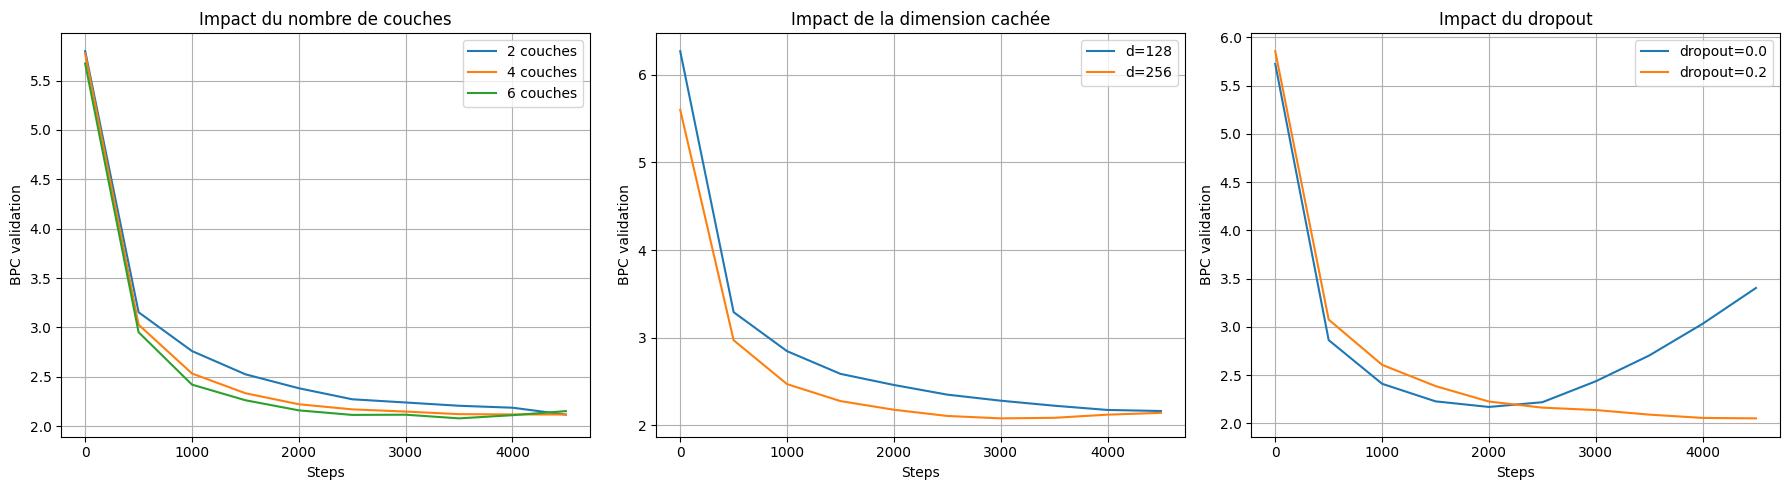

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Expérience 1 — nombre de couches
ax = axes[0]
for n_couches, hist in resultats_couches.items():
    ax.plot(hist['steps'], hist['bpc_val'], label=f'{n_couches} couches')
ax.set_title('Impact du nombre de couches')
ax.set_xlabel('Steps')
ax.set_ylabel('BPC validation')
ax.legend()
ax.grid(True)

# Expérience 2 — dimension cachée
ax = axes[1]
for d_modele, hist in resultats_dim.items():
    ax.plot(hist['steps'], hist['bpc_val'], label=f'd={d_modele}')
ax.set_title('Impact de la dimension cachée')
ax.set_xlabel('Steps')
ax.set_ylabel('BPC validation')
ax.legend()
ax.grid(True)

# Expérience 3 — dropout
ax = axes[2]
for dropout, hist in resultats_dropout.items():
    ax.plot(hist['steps'], hist['bpc_val'], label=f'dropout={dropout}')
ax.set_title('Impact du dropout')
ax.set_xlabel('Steps')
ax.set_ylabel('BPC validation')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig('hyperparametres.png', dpi=150)
plt.show()

## Étape IV — Analyse des poèmes générés

Une fois le modèle entraîné, nous analysons les textes qu'il produit afin de
déterminer si les propriétés structurelles du corpus d'entraînement réapparaissent
dans les générations : longueur des vers, structure des strophes, schémas de rimes.

### 1. Génération de poèmes

In [34]:
def generer_poeme(prompt_texte='', longueur=500, temperature=0.8, top_k=40):
    """
    Génère un poème à partir d'un prompt textuel.

    Paramètres
    ----------
    prompt_texte : texte de départ (vide = génération libre)
    longueur     : nombre de caractères à générer
    temperature  : créativité (< 1 = plus déterministe, > 1 = plus aléatoire)
    top_k        : restreint l'échantillonnage aux k caractères les plus probables
    """
    modele.eval()

    if prompt_texte:
        indices_prompt = torch.tensor(
            encoder(prompt_texte), dtype=torch.long, device=dispositif
        ).unsqueeze(0)
    else:
        indices_prompt = torch.zeros((1, 1), dtype=torch.long, device=dispositif)

    indices_generes = modele.generer(
        indices_prompt, longueur, temperature=temperature, top_k=top_k
    )
    return decoder(indices_generes[0].tolist())


# Génération avec différentes températures
for temperature in [0.5, 0.8, 1.0, 1.2]:
    print(f"\n{'='*50}")
    print(f"Température : {temperature}")
    print('='*50)
    print(generer_poeme(longueur=300, temperature=temperature))


Température : 0.5

                                                            11
    X VIEILLE CHANSON DU JEUNE TEMPS                                    15
   XX MAGNIT                                                        133
  XXI Il lui disait                                              135
  XXII Aimons toujour

Température : 0.8


  LE POÈTE

  I


  La tristesse à tât n'est pas un négligé
  Dont le rêve écrit l'enfer an on est noir.

  C'est la Voix qui pleure aux traits et froids comme un mot
  Qui surveille la reine du boucher,
  Les forêts je veux abritement comme une faux demain
  Qui donne un caillou sa lumière aux roc

Température : 1.0

Quoiques pourprentes, oh! quels pas de joie
L'élas en eux, Jésus-Christ bien et pour fier,
L'aube, qui monte dans l'oubli mon amour
D'une lampe sur langoureuse atrice
Pour les bois et qu'on jette au vol oiseau.

Dans un grand écrivain joyeux mort
Que le mal et qui le trahie un peu nial
Se sentir plu

Température : 1.2

Comme un bouquet 

### 2. Analyse de la longueur des vers

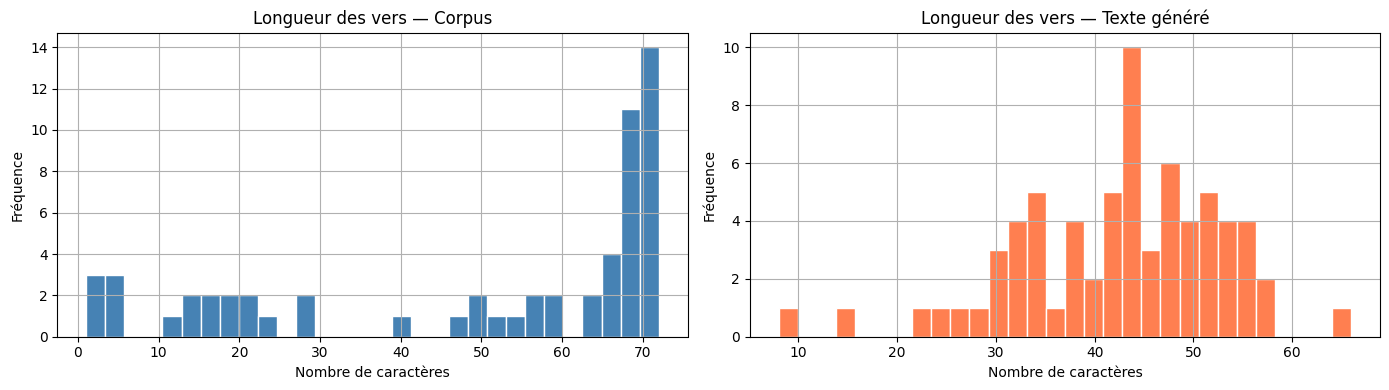

Longueur moyenne — Corpus  : 49.4 caractères
Longueur moyenne — Générés : 42.3 caractères


In [35]:
def extraire_vers(texte):
    """Extrait les vers non vides d'un texte poétique."""
    return [ligne for ligne in texte.split('\n') if ligne.strip()]

def analyser_longueur_vers(texte):
    """Retourne la liste des longueurs de vers d'un texte."""
    return [len(vers) for vers in extraire_vers(texte)]

# Génération d'un large échantillon pour l'analyse
texte_genere = generer_poeme(longueur=3000, temperature=0.8)

# Analyse du corpus d'entraînement (échantillon)
echantillon_corpus = decoder(donnees_entrainement[:3000].tolist())

longueurs_corpus  = analyser_longueur_vers(echantillon_corpus)
longueurs_generes = analyser_longueur_vers(texte_genere)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(longueurs_corpus,  bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Longueur des vers — Corpus')
axes[0].set_xlabel('Nombre de caractères')
axes[0].set_ylabel('Fréquence')
axes[0].grid(True)

axes[1].hist(longueurs_generes, bins=30, color='coral', edgecolor='white')
axes[1].set_title('Longueur des vers — Texte généré')
axes[1].set_xlabel('Nombre de caractères')
axes[1].set_ylabel('Fréquence')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('longueur_vers.png', dpi=150)
plt.show()

print(f"Longueur moyenne — Corpus  : {sum(longueurs_corpus)/len(longueurs_corpus):.1f} caractères")
print(f"Longueur moyenne — Générés : {sum(longueurs_generes)/len(longueurs_generes):.1f} caractères")

### 3. Analyse des strophes

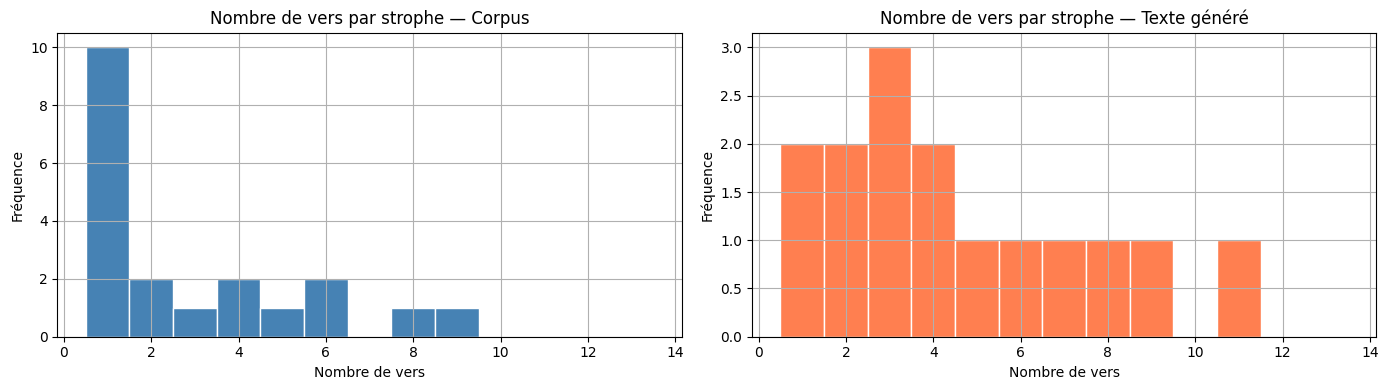

Taille moyenne des strophes — Corpus  : 3.0 vers
Taille moyenne des strophes — Générés : 4.6 vers


In [36]:
def extraire_strophes(texte):
    """
    Extrait les strophes d'un texte poétique.
    Une strophe est délimitée par une ligne vide.
    """
    strophes = texte.strip().split('\n\n')
    return [s.strip() for s in strophes if s.strip()]

def analyser_strophes(texte):
    strophes = extraire_strophes(texte)
    tailles  = [len(extraire_vers(s)) for s in strophes]
    return tailles

tailles_corpus  = analyser_strophes(echantillon_corpus)
tailles_generes = analyser_strophes(texte_genere)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(tailles_corpus,  bins=range(1, 15), color='steelblue',
             edgecolor='white', align='left')
axes[0].set_title('Nombre de vers par strophe — Corpus')
axes[0].set_xlabel('Nombre de vers')
axes[0].set_ylabel('Fréquence')
axes[0].grid(True)

axes[1].hist(tailles_generes, bins=range(1, 15), color='coral',
             edgecolor='white', align='left')
axes[1].set_title('Nombre de vers par strophe — Texte généré')
axes[1].set_xlabel('Nombre de vers')
axes[1].set_ylabel('Fréquence')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('structure_strophes.png', dpi=150)
plt.show()

print(f"Taille moyenne des strophes — Corpus  : {sum(tailles_corpus)/len(tailles_corpus):.1f} vers")
print(f"Taille moyenne des strophes — Générés : {sum(tailles_generes)/len(tailles_generes):.1f} vers")

### 4. Analyse des rimes

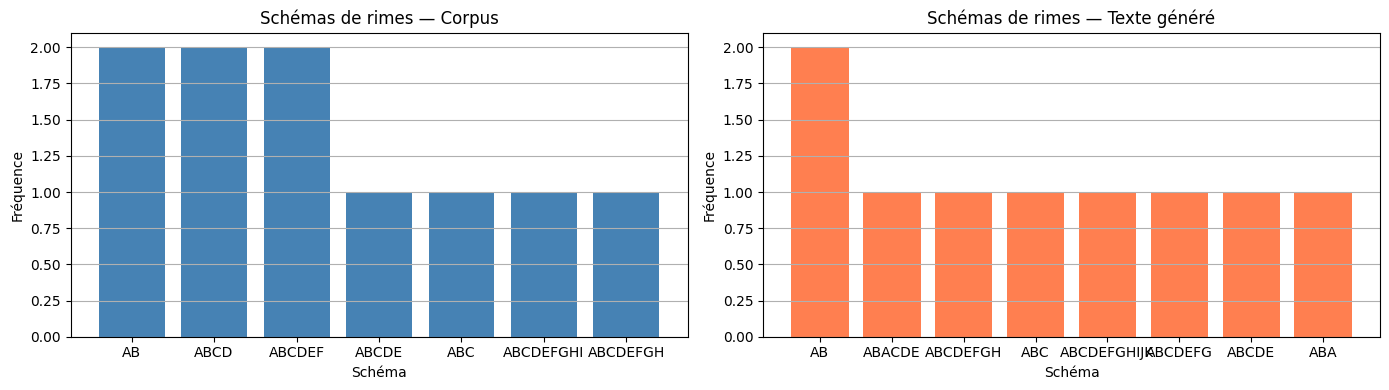

In [37]:
def extraire_fin_vers(vers, n_chars=3):
    """Extrait les n derniers caractères d'un vers (approximation de la rime)."""
    vers = vers.strip().rstrip('.,;:!?')
    return vers[-n_chars:].lower() if len(vers) >= n_chars else vers.lower()

def detecter_schema_rimes(strophe):
    """
    Détecte le schéma de rimes d'une strophe (ex: ABAB, AABB).
    Retourne une chaîne de lettres représentant le schéma.
    """
    vers = extraire_vers(strophe)
    if len(vers) < 2:
        return None

    fins       = [extraire_fin_vers(v) for v in vers]
    schema     = []
    lettre_map = {}
    lettre_courante = ord('A')

    for fin in fins:
        if fin not in lettre_map:
            lettre_map[fin] = chr(lettre_courante)
            lettre_courante += 1
        schema.append(lettre_map[fin])

    return ''.join(schema)

def analyser_rimes(texte):
    strophes = extraire_strophes(texte)
    schemas  = [detecter_schema_rimes(s) for s in strophes]
    schemas  = [s for s in schemas if s]
    return schemas

schemas_corpus  = analyser_rimes(echantillon_corpus)
schemas_generes = analyser_rimes(texte_genere)

# Comptage des schémas les plus fréquents
from collections import Counter

top_corpus  = Counter(schemas_corpus).most_common(8)
top_generes = Counter(schemas_generes).most_common(8)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar([s for s, _ in top_corpus],  [c for _, c in top_corpus],
            color='steelblue')
axes[0].set_title('Schémas de rimes — Corpus')
axes[0].set_xlabel('Schéma')
axes[0].set_ylabel('Fréquence')
axes[0].grid(True, axis='y')

axes[1].bar([s for s, _ in top_generes], [c for _, c in top_generes],
            color='coral')
axes[1].set_title('Schémas de rimes — Texte généré')
axes[1].set_xlabel('Schéma')
axes[1].set_ylabel('Fréquence')
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.savefig('schemas_rimes.png', dpi=150)
plt.show()

### 5. Exemples de poèmes générés

In [39]:
# Génération avec prompt tiré du corpus
prompts = [
    "Demain, dès l'aube",
    "Les sanglots longs",
    "Mon enfant, ma soeur",
    "Je suis la plaie et le couteau",
]

for prompt in prompts:
    print(f"\n{'='*50}")
    print(f"Prompt : « {prompt} »")
    print('='*50)
    print(generer_poeme(
        prompt_texte=prompt,
        longueur=300,
        temperature=0.8,
        top_k=40
    ))


Prompt : « Demain, dès l'aube »
Demain, dès l'aube et qui l'amour malicienne leurs beaux.

Monsieur Nialinade peuplier leur tenture usiles
Apparente les coeurs dde tout le noir contre la marquis,
Et qu'ils ont fait ce sourire, et qu'il est de la paix airs
Et que les coeurs aient peuvrent à ces branches sont ces feuilles
Où le Racin m'est pour le mo

Prompt : « Les sanglots longs »
Les sanglots longs dans l'histoire;
L'ombre éteints en pleurs sur la bouche;
L'aurore, frais, l'aube, et Police, ou boir,
L'ange fait sa parente au vil Paris;
Quand parmi les chères errants on voit les mots:
Telles, ils l'sont des choses à l'aile de la rie.
Les feuillaient en prière les ailes de femmes;
Les femmes qu

Prompt : « Mon enfant, ma soeur »
Mon enfant, ma soeur, je vous cherche et vous.

Mai 1843.


XII


A M. FROMENT MEURICE


Nous sommes frères: la fleur
Par les os purs est pour jamais les roses;
Pour nous rasimerons avec les voix jamais!
C'est toute le navire ou sous les ramures,
C'est le Dieu 